In [2]:
!pip install transformers datasets accelerate scikit-learn


In [5]:
!ls

dataset.csv  sample_data


In [6]:
import pandas as pd

df = pd.read_csv("dataset.csv", engine='python', on_bad_lines='skip')
# Keep only required columns
df = df[["text", "is_rumor"]]

# Remove missing values
df = df.dropna()

# Convert labels to int
df["is_rumor"] = df["is_rumor"].astype(int)

print("Dataset shape:", df.shape)
print(df["is_rumor"].value_counts())
df.head()

Dataset shape: (62443, 2)
is_rumor
0    48619
1    13824
Name: count, dtype: int64


,text,is_rumor
0,Charlie Hebdo became well known for publishing...,0
1,"Now 10 dead in a shooting there today RT ""@BBC...",0
2,@BBCDanielS @BBCWorld I'm guessing this is bei...,0
3,@BBCDanielS @BBCWorld why would you mention th...,0
4,@BBCDanielS @BBCWorld perps identified?,0


In [5]:
from sklearn.model_selection import train_test_split

train_texts, val_texts, train_labels, val_labels = train_test_split(
    df["text"].tolist(),
    df["is_rumor"].tolist(),
    test_size=0.2,
    random_state=42
)

print("Train size:", len(train_texts))
print("Validation size:", len(val_texts))

Train size: 49954
Validation size: 12489


In [6]:
from transformers import RobertaTokenizer

tokenizer = RobertaTokenizer.from_pretrained("roberta-base")

train_encodings = tokenizer(
    train_texts,
    truncation=True,
    padding=True,
    max_length=128
)

val_encodings = tokenizer(
    val_texts,
    truncation=True,
    padding=True,
    max_length=128
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

In [7]:
df["is_rumor"].value_counts()

,count
is_rumor,
0,48619
1,13824


In [8]:
import torch

class RumorDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

In [9]:
train_dataset = RumorDataset(train_encodings, train_labels)
val_dataset = RumorDataset(val_encodings, val_labels)

In [10]:
from transformers import RobertaForSequenceClassification

model = RobertaForSequenceClassification.from_pretrained(
    "roberta-base",
    num_labels=2
)

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.weight      | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [11]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
import torch

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_labels),
    y=train_labels
)

class_weights = torch.tensor(class_weights, dtype=torch.float)

print("Class Weights:", class_weights)

Class Weights: tensor([0.6427, 2.2524])


In [12]:
from transformers import Trainer
import torch.nn as nn

class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.get("labels")

        outputs = model(**inputs)
        logits = outputs.get("logits")

        loss_fct = nn.CrossEntropyLoss(weight=class_weights.to(model.device))
        loss = loss_fct(logits, labels)

        return (loss, outputs) if return_outputs else loss

In [13]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./results",
    num_train_epochs=3,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    logging_dir="./logs"
)

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [16]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
import numpy as np

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, predictions, average='binary'
    )
    acc = accuracy_score(labels, predictions)

    return {
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1": f1,
    }

In [17]:
trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics
)

In [ ]:
trainer.train()

Step,Training Loss
500,0.707198
1000,0.698626
1500,0.705377
2000,0.711745
2500,0.703434
3000,0.704265
3500,0.719725
4000,0.701863
4500,0.712180
5000,0.709686


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [7]:
from sklearn.model_selection import train_test_split

# Re-perform train_test_split to ensure variables are defined
# Assuming 'df' is available from previous cells (cell aiqSr1UqYrg5)
train_texts, val_texts, train_labels, val_labels = train_test_split(
    df["text"].tolist(),
    df["is_rumor"].tolist(),
    test_size=0.2,
    random_state=42
)

# Use smaller subset
train_texts_small = train_texts[:15000]
train_labels_small = train_labels[:15000]

val_texts_small = val_texts[:4000]
val_labels_small = val_labels[:4000]

print("Train small size:", len(train_texts_small))
print("Validation small size:", len(val_texts_small))

Train small size: 15000
Validation small size: 4000


In [8]:
from transformers import RobertaTokenizer, RobertaForSequenceClassification

tokenizer = RobertaTokenizer.from_pretrained("distilroberta-base")

model = RobertaForSequenceClassification.from_pretrained(
    "distilroberta-base",
    num_labels=2
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/480 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/331M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/101 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: distilroberta-base
Key                         | Status     | 
----------------------------+------------+-
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
classifier.out_proj.bias    | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.bias       | MISSING    | 
classifier.dense.weight     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [9]:
train_encodings = tokenizer(
    train_texts_small,
    truncation=True,
    padding=True,
    max_length=64
)

val_encodings = tokenizer(
    val_texts_small,
    truncation=True,
    padding=True,
    max_length=64
)

In [10]:
import torch

class RumorDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

train_dataset = RumorDataset(train_encodings, train_labels_small)
val_dataset = RumorDataset(val_encodings, val_labels_small)

In [11]:
for param in model.roberta.parameters():
    param.requires_grad = False

In [12]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_labels_small),
    y=train_labels_small
)

class_weights = torch.tensor(class_weights, dtype=torch.float)
print("Class Weights:", class_weights)

Class Weights: tensor([0.6427, 2.2523])


In [13]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, predictions, average='binary'
    )
    acc = accuracy_score(labels, predictions)

    return {
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1": f1,
    }

In [14]:
from transformers import Trainer
import torch.nn as nn

class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.get("labels")

        outputs = model(**inputs)
        logits = outputs.get("logits")

        loss_fct = nn.CrossEntropyLoss(weight=class_weights.to(model.device))
        loss = loss_fct(logits, labels)

        return (loss, outputs) if return_outputs else loss

In [15]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./results",
    num_train_epochs=2,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    learning_rate=2e-5,
    logging_steps=500
)

In [16]:
trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics
)

In [17]:
trainer.train()

Step,Training Loss
500,0.690253
1000,0.683503
1500,0.681568


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=1876, training_loss=0.6837870795081165, metrics={'train_runtime': 81.821, 'train_samples_per_second': 366.654, 'train_steps_per_second': 22.928, 'total_flos': 496752744960000.0, 'train_loss': 0.6837870795081165, 'epoch': 2.0})

In [18]:
trainer.evaluate()

{'eval_loss': 0.6779699921607971,
 'eval_accuracy': 0.721,
 'eval_precision': 0.3996524761077324,
 'eval_recall': 0.519774011299435,
 'eval_f1': 0.4518664047151277,
 'eval_runtime': 7.86,
 'eval_samples_per_second': 508.907,
 'eval_steps_per_second': 31.807,
 'epoch': 2.0}

In [20]:
# Slightly larger dataset (better learning)
train_texts_small = train_texts[:20000]
train_labels_small = train_labels[:20000]

val_texts_small = val_texts[:5000]
val_labels_small = val_labels[:5000]

In [21]:
from transformers import RobertaTokenizer, RobertaForSequenceClassification

tokenizer = RobertaTokenizer.from_pretrained("distilroberta-base")

model = RobertaForSequenceClassification.from_pretrained(
    "distilroberta-base",
    num_labels=2
)

Loading weights:   0%|          | 0/101 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: distilroberta-base
Key                         | Status     | 
----------------------------+------------+-
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
classifier.out_proj.bias    | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.bias       | MISSING    | 
classifier.dense.weight     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [22]:
for name, param in model.named_parameters():
    if "roberta.encoder.layer.0" in name or \
       "roberta.encoder.layer.1" in name or \
       "roberta.encoder.layer.2" in name:
        param.requires_grad = False

In [23]:
train_encodings = tokenizer(
    train_texts_small,
    truncation=True,
    padding=True,
    max_length=64
)

val_encodings = tokenizer(
    val_texts_small,
    truncation=True,
    padding=True,
    max_length=64
)

In [24]:
import torch

class RumorDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

train_dataset = RumorDataset(train_encodings, train_labels_small)
val_dataset = RumorDataset(val_encodings, val_labels_small)

In [25]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_labels_small),
    y=train_labels_small
)

class_weights = torch.tensor(class_weights, dtype=torch.float)
print("Class Weights:", class_weights)

Class Weights: tensor([0.6418, 2.2624])


In [26]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, predictions, average='binary'
    )
    acc = accuracy_score(labels, predictions)

    return {
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1": f1,
    }

In [27]:
from transformers import Trainer
import torch.nn as nn

class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.get("labels")

        outputs = model(**inputs)
        logits = outputs.get("logits")

        loss_fct = nn.CrossEntropyLoss(weight=class_weights.to(model.device))
        loss = loss_fct(logits, labels)

        return (loss, outputs) if return_outputs else loss

In [28]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./results",
    num_train_epochs=3,          # Increased
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    learning_rate=2e-5,
    logging_steps=500
)

In [29]:
trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics
)

In [30]:
trainer.train()

Step,Training Loss
500,0.623700
1000,0.564814
1500,0.496964
2000,0.461782
2500,0.436655
3000,0.390415
3500,0.361194


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=3750, training_loss=0.46894754638671876, metrics={'train_runtime': 655.4083, 'train_samples_per_second': 91.546, 'train_steps_per_second': 5.722, 'total_flos': 993505489920000.0, 'train_loss': 0.46894754638671876, 'epoch': 3.0})

In [31]:
trainer.evaluate()

{'eval_loss': 0.4642203152179718,
 'eval_accuracy': 0.8268,
 'eval_precision': 0.5797198132088058,
 'eval_recall': 0.7864253393665158,
 'eval_f1': 0.6674347158218126,
 'eval_runtime': 9.0765,
 'eval_samples_per_second': 550.875,
 'eval_steps_per_second': 34.485,
 'epoch': 3.0}

In [33]:
import torch
import torch.nn.functional as F

def predict_credibility(text):
    model.eval()

    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=64
    )

    inputs = {key: val.to(model.device) for key, val in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs)
        probs = F.softmax(outputs.logits, dim=1)

    rumor_prob = probs[0][1].item()
    credibility_score = 1 - rumor_prob

    # 🔥 Adjusted threshold from 0.5 → 0.4
    label = "Credible" if credibility_score > 0.4 else "Non-Credible"

    return {
        "credibility_score": credibility_score,
        "label": label
    }

In [34]:
predict_credibility("Breaking news: major flood in Colombo city.")

{'credibility_score': 0.8615376800298691, 'label': 'Credible'}

In [35]:
import numpy as np

# Get predictions
predictions = trainer.predict(val_dataset)

logits = predictions.predictions
true_labels = predictions.label_ids

pred_labels = np.argmax(logits, axis=1)

In [36]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(true_labels, pred_labels)

print("Confusion Matrix:\n", cm)

Confusion Matrix:
 [[3265  630]
 [ 236  869]]


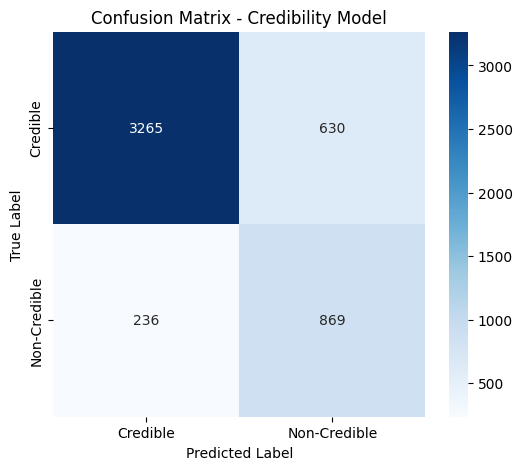

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Credible", "Non-Credible"],
    yticklabels=["Credible", "Non-Credible"]
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Credibility Model")

plt.show()